# Preprocessing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
working_dir = os.getcwd()
FOLDER_NAME = os.path.basename(working_dir)
FILE_NAME = 'macd_xlstm'

STOCK = 'BTC    '
FREQ = '30min'
level = 2

TRADE_PRICE = 'close'
# TRADE_PRICE = 'open'
# TRADE_PRICE = 'low'
# TRADE_PRICE = 'high'



SEQ_LENGTH = 28
BATCH_SIZE = 8

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)

In [3]:
os.chdir(os.path.join('..','data'))
df = pd.read_csv(f'{STOCK}USD_2023_2024.csv', index_col='Gmt time')
df.index = pd.to_datetime(df.index, format="%d.%m.%Y %H:%M:%S.%f", errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})

In [4]:
os.chdir('..')
from utils.utils import CreateTimeFrames
df = CreateTimeFrames(df, [FREQ])[FREQ]
df = df.iloc[-4050:,:]

In [5]:
close = df[f'{TRADE_PRICE}'].to_numpy(dtype=np.int32)
print(f'There are {close.size} {TRADE_PRICE} prices.')

There are 4050 close prices.


In [6]:
train = close[:int(np.ceil(TRAIN_SPLIT*len(close)))]
val = close[int(np.ceil(TRAIN_SPLIT*len(close))): int(np.ceil( (TRAIN_SPLIT+VAL_SPLIT)*len(close) ))]
test = close[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(close))):]
assert len(train) + len(val) + len(test) == len(df), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train.size}, val size:{val.size}, test size:{test.size}.')


train size:2835, val size:405, test size:810.


In [7]:
os.chdir('denoise')
from dwt import *
os.chdir(os.path.join('..', 'macdxlstm'))

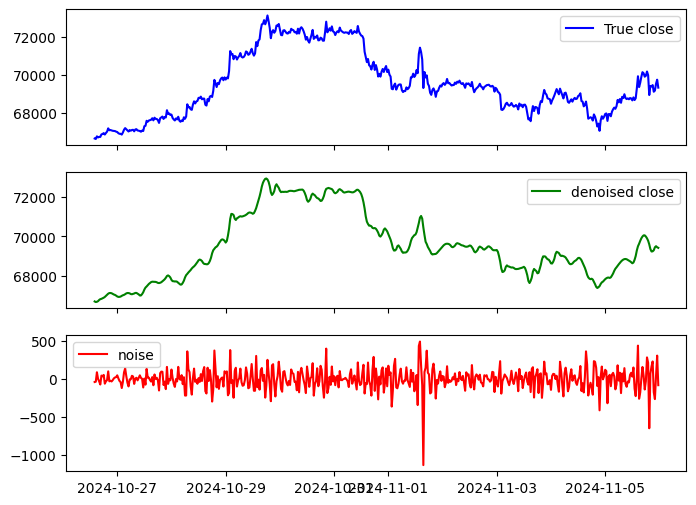

In [8]:
df[f'smoothed_data_{TRADE_PRICE}'] = wavelet_denoising(df[f'{TRADE_PRICE}'], level=level)
df['noise'] = df[f'{TRADE_PRICE}'] - df[f'smoothed_data_{TRADE_PRICE}']

import matplotlib.pyplot as plt
# fig = plt.figure(figsize=(8,6))
fig, axs = plt.subplots(3,1, figsize=(8,6), sharex=True)

axs[0].plot(df[f'{TRADE_PRICE}'].iloc[-500:], color = 'blue', label='True close')
axs[0].legend()

axs[1].plot(df[f'smoothed_data_{TRADE_PRICE}'].iloc[-500:], color = 'green', label='denoised close')
axs[1].legend()

axs[2].plot(df['noise'].iloc[-500:], color = 'red', label = 'noise')
axs[2].legend()


# MACD optimization

In [9]:
os.chdir(os.path.join('..', 'genetic'))
from classes import KalmanFilterEM, MACD_GA_v2
os.chdir(os.path.join('..', 'macdxlstm'))


## Create sequence

In [10]:
def create_sequences(data, seq_length):
    sequences = []
    for i in range(len(data) - seq_length + 1):
        sequences.append(data[i:i + seq_length])
    return np.array(sequences, dtype=np.int64)

sequences = create_sequences(df[f'smoothed_data_{TRADE_PRICE}'].values, SEQ_LENGTH)
print(f'Created {len(sequences)} sequences of length {SEQ_LENGTH}.')

Created 4023 sequences of length 28.


In [11]:
def optimize_macd(df, real_price = f'{TRADE_PRICE}', signal_price=f'smoothed_data_{TRADE_PRICE}'):

    # Initialize the optimizer
    optimizer = MACD_GA_v2(df_train=df, real_price = real_price, signal_price=signal_price)
    
    # Run the genetic algorithm
    optimizer.run_ga()
    
    # Get the best parameters
    best_params = optimizer.get_best_parameters()
    return best_params

In [12]:
best_macd_coefficients = np.zeros((len(sequences), 3), dtype=np.int8)

for i, seq in enumerate(sequences):

    df_macd = pd.DataFrame({
        'seq':seq,
        f'{TRADE_PRICE}':df[f'{TRADE_PRICE}'][i:i+SEQ_LENGTH],
        f'smoothed_data_{TRADE_PRICE}': df[f'smoothed_data_{TRADE_PRICE}'][i:i+SEQ_LENGTH]
    })

    x = optimize_macd(df_macd, real_price=TRADE_PRICE, signal_price=f'smoothed_data_{TRADE_PRICE}')
    best_macd_coefficients[i,0] = x.get('Fast EMA')
    best_macd_coefficients[i,1] = x.get('Slow EMA')
    best_macd_coefficients[i,2] = x.get('Signal Line')
    print(i)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [13]:
best_macd_coefficients.shape

(4023, 3)

In [14]:
path = f'./{SEQ_LENGTH}_{STOCK}_{FREQ}'

try:
    os.mkdir(path)
    print(f"Directory '{path}' created successfully.")
except FileExistsError:
    print(f"Directory '{path}' already exists.")
except Exception as e:
    print(f"An error occurred: {e}")

Directory './28_BTC_30min' created successfully.


In [15]:
os.getcwd()

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\macdxlstm'

In [16]:
np.save(f'{SEQ_LENGTH}_{STOCK}_{FREQ}/best_macd_coefficients_{TRADE_PRICE}_{FREQ}.npy', best_macd_coefficients)
# # np.load

In [17]:
os.getcwd()

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src\\macdxlstm'

In [18]:
# best_macd_coefficients = np.load(f'{SEQ_LENGTH}_{STOCK}_{FREQ}/best_macd_coefficients_{TRADE_PRICE}_{FREQ}.npy')

In [19]:
def calculate_ema(values, period):
    return pd.Series(values).ewm(span=period, adjust=False).mean().values

def calculate_macd(sequence, fast_period, slow_period, signal_period):
    # calculate macd things for a sequence.
    macd_line = calculate_ema(sequence, fast_period)-calculate_ema(sequence, slow_period)
    signal_line = calculate_ema(macd_line, signal_period)
    histogram = macd_line-signal_line
    return macd_line, signal_line, histogram



In [20]:
macd_lines = []
signal_lines = []
histograms = []

In [21]:
for i, seq in enumerate(sequences):
    f,s,h = best_macd_coefficients[i]
    macd_line, signal_line, histogram = calculate_macd(seq, fast_period=f,slow_period=s,signal_period=h)
    macd_lines.append(macd_line)
    signal_lines.append(signal_line)
    histograms.append(histogram)

macd_lines = np.array(macd_lines)
signal_lines = np.array(signal_lines)
histograms = np.array(histograms)

In [22]:
def label_sequence(macd_lines, signal_lines ):

    a, b = macd_lines.shape
    labels = np.zeros((a,b), dtype=np.int8)
    for i in range(0,a):
        # a = 3931
        for j in range(2, b):
            # b = 120

            if macd_lines[i,j] > signal_lines[i,j] and macd_lines[i, j-1]<=signal_lines[i, j-1]:
                labels[i, j] = 1 # Buy
            elif macd_lines[i,j] < signal_lines[i,j] and macd_lines[i, j-1] >=signal_lines[i,j-1]:
                labels[i,j] = -1 # Sell

    return labels

In [23]:
sequence_labels = label_sequence(macd_lines, signal_lines)
sequence_labels = np.array(sequence_labels)

In [24]:
def catch_the_best(df, sequences, seq_len=SEQ_LENGTH):
    the_best_values = np.zeros(len(df))
    s = len(df)-seq_len + 1
    for i in range(s):
        the_best_values[i] = sequences[i,-1]


    the_best_values[s-1:] = sequences[-1,:]
        # if i == s:
        #     the_best_values[i:] = sequences[i,:]
        # else:
        #     the_best_values[i] = sequences[i,-1]

    return the_best_values

In [25]:
data_labels = catch_the_best(df, sequence_labels)

In [26]:
num_buy = np.count_nonzero(data_labels==1)
print(f'num_buy is: {num_buy}.')

num_sell = np.count_nonzero(data_labels==-1)
print(f'num_sell is: {num_sell}.')

num_hold = np.count_nonzero(data_labels==0)
print(f'num_hold is: {num_hold}.')
assert num_buy+num_sell+num_hold == len(df), 'Some data are ignored.'

num_buy is: 316.
num_sell is: 307.
num_hold is: 3427.


In [27]:
def enforce_trade_sequence(data_labels):
    """
    Ensure that the sequence of Buy/Sell labels results in an equal number of Buy and Sell signals
    or one more Buy/Sell signal, adhering to trading rules.
    """
    corrected_labels = np.zeros_like(data_labels, dtype=np.int8)
    last_trade = 0  # 0 indicates no trade yet, 1 = Buy, -1 = Sell
    num_buy = 0
    num_sell = 0

    for i, label in enumerate(data_labels):
        if label == 1:  # Current signal is Buy
            if last_trade in [0, -1]:  # Valid only after Sell or no trade
                corrected_labels[i] = 1
                last_trade = 1
                num_buy += 1
            else:  # Invalid Buy; replace with Hold
                corrected_labels[i] = 0

        elif label == -1:  # Current signal is Sell
            if last_trade == 1:  # Valid only after Buy
                corrected_labels[i] = -1
                last_trade = -1
                num_sell += 1
            else:  # Invalid Sell; replace with Hold
                corrected_labels[i] = 0

        else:  # Current signal is Hold
            corrected_labels[i] = 0  # Always valid

    if last_trade == 1:
        corrected_labels[-1] = -1
        num_sell += 1

    return corrected_labels, num_buy, num_sell


In [28]:
# Correct the sequence to ensure valid trade rules
data_labels, final_num_buy, final_num_sell = enforce_trade_sequence(data_labels)

print(f"Final num_buy is: {final_num_buy}.")
print(f"Final num_sell is: {final_num_sell}.")
assert abs(final_num_buy - final_num_sell) <= 1, "Number of Buy and Sell trades must be equal or differ by one."


Final num_buy is: 204.
Final num_sell is: 204.


In [29]:
df['labels'] = data_labels

In [30]:
macd_line_new = catch_the_best(df,macd_lines)
signal_line_new = catch_the_best(df, signal_lines)
histogram_new = catch_the_best(df,histograms)

In [31]:
def replace_zeros_with_mean(arr):
    # Create a copy of the array to avoid modifying the original during iteration
    modified_array = arr.copy()
    
    # Iterate through the array starting from index 1 to len(arr) - 2
    for i in range(1, len(arr) - 1):
        if arr[i] == 0:
            # Calculate mean of previous and next elements
            mean_value = (arr[i - 1] + arr[i + 1]) / 2
            modified_array[i] = mean_value
            
    return modified_array

In [32]:
macd_lines.shape

(4023, 28)

In [33]:
macd_line_new = replace_zeros_with_mean(macd_line_new)
signal_line_new = replace_zeros_with_mean(signal_line_new)
histogram_new = replace_zeros_with_mean(histogram_new)

In [34]:
df['macd_line'] = macd_line_new
df['signal_line'] = signal_line_new
df['histogram'] = histogram_new

In [35]:
np.save(f'{SEQ_LENGTH}/macd_line_{SEQ_LENGTH}_{TRADE_PRICE}.npy',macd_line_new)
np.save(f'{SEQ_LENGTH}/signal_line_{SEQ_LENGTH}_{TRADE_PRICE}.npy', signal_line_new)
np.save(f'{SEQ_LENGTH}/histogram_{SEQ_LENGTH}_{TRADE_PRICE}.npy', histogram_new)


# Show me

In [36]:
df

,open,high,low,close,volume,smoothed_data_close,noise,labels,macd_line,signal_line,histogram
2024-08-13 15:00:00,59614,59696,59362,59463,46912.0002,59551.806814,-88.806814,0,136.189132,141.886153,-5.697022
2024-08-13 15:30:00,59463,59510,59330,59452,45170.0000,59934.397255,-482.397255,0,4.882652,17.383684,-12.501032
2024-08-13 16:00:00,59452,60108,59428,59896,46381.0005,60480.671618,-584.671618,0,-26.558676,-11.911226,-14.647451
2024-08-13 16:30:00,59896,61154,59887,61135,56272.9998,60808.233635,326.766365,0,-36.261241,-17.169206,-19.092035
2024-08-13 17:00:00,61136,61452,60947,61273,53925.9999,60881.294633,391.705367,0,-53.353135,-28.071615,-25.281520
...,...,...,...,...,...,...,...,...,...,...,...
2024-11-05 21:30:00,69480,69570,69051,69129,11461.0000,69302.154340,-173.154340,1,-104.075039,-113.947253,9.872214
2024-11-05 22:00:00,69126,69260,68853,69188,9004.0000,69451.663977,-263.663977,0,-44.367135,-79.157194,34.790059
2024-11-05 22:30:00,69189,69556,69189,69548,7812.0000,69507.114045,40.885955,0,-4.704721,-41.930957,37.226236
2024-11-05 23:00:00,69548,69761,69450,69761,12804.0000,69453.454416,307.545584,0,-1.438899,-21.684928,20.246029


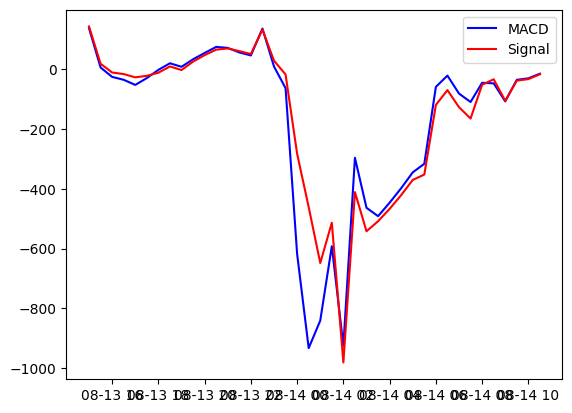

In [37]:
plt.plot(df['macd_line'][:40], color = 'blue', label = 'MACD')
plt.plot(df['signal_line'][:40], color = 'red', label='Signal')
plt.legend()

In [38]:
df.columns

Index(['open', 'high', 'low', 'close', 'volume', 'smoothed_data_close',
       'noise', 'labels', 'macd_line', 'signal_line', 'histogram'],
      dtype='object')

## Feature inputs

In [39]:
x = df[['macd_line','signal_line', 'histogram']].copy()
y = df['labels'].copy

In [40]:
x

,macd_line,signal_line,histogram
2024-08-13 15:00:00,136.189132,141.886153,-5.697022
2024-08-13 15:30:00,4.882652,17.383684,-12.501032
2024-08-13 16:00:00,-26.558676,-11.911226,-14.647451
2024-08-13 16:30:00,-36.261241,-17.169206,-19.092035
2024-08-13 17:00:00,-53.353135,-28.071615,-25.281520
...,...,...,...
2024-11-05 21:30:00,-104.075039,-113.947253,9.872214
2024-11-05 22:00:00,-44.367135,-79.157194,34.790059
2024-11-05 22:30:00,-4.704721,-41.930957,37.226236
2024-11-05 23:00:00,-1.438899,-21.684928,20.246029


## Create sequence of features

In [41]:
x_seq = create_sequences(x, SEQ_LENGTH)

## Encode output

In [42]:
y_enc = pd.get_dummies(df['labels'], prefix='y', drop_first=False)

In [43]:
y_enc

,y_-1,y_0,y_1
2024-08-13 15:00:00,False,True,False
2024-08-13 15:30:00,False,True,False
2024-08-13 16:00:00,False,True,False
2024-08-13 16:30:00,False,True,False
2024-08-13 17:00:00,False,True,False
...,...,...,...
2024-11-05 21:30:00,False,False,True
2024-11-05 22:00:00,False,True,False
2024-11-05 22:30:00,False,True,False
2024-11-05 23:00:00,False,True,False


In [44]:
x_seq.shape

(4023, 28, 3)

## step 6: Set output feature. 

In [45]:
y_enc_adjust = y_enc[:-1].to_numpy()
x_seq_adjust = x_seq[1:]

In [46]:
print(f'y_enc_adjust.shape is: {y_enc_adjust.shape}')
print(f'x_seq_adjust.shape is: {x_seq_adjust.shape}')

y_enc_adjust.shape is: (4049, 3)
x_seq_adjust.shape is: (4022, 28, 3)


In [47]:
y_enc_adjust = y_enc_adjust[SEQ_LENGTH-1:]
print(f'y_enc_adjust.shape is: {y_enc_adjust.shape}')

y_enc_adjust.shape is: (4022, 3)


# Split data set

In [48]:
len(x_seq_adjust)

4022

In [49]:
train_x = x_seq_adjust[:int(np.floor(TRAIN_SPLIT*len(x_seq_adjust)))]
val_x= x_seq_adjust[int(np.ceil(TRAIN_SPLIT*len(x_seq_adjust))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(x_seq_adjust) ))]
test_x= x_seq_adjust[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(x_seq_adjust))):]
assert len(train_x) + len(val_x) + len(test_x) == len(x_seq_adjust), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train_x.shape[0]}, val size:{val_x.shape[0]}, test size:{test_x.shape[0]}.')


AssertionError: The dimension of price is dividable to SPLIT numbers. Splited len is:4050 but df len is:4050 

In [ ]:
train_y = y_enc_adjust[:int(np.floor(TRAIN_SPLIT*len(x_seq_adjust)))]
val_y= y_enc_adjust[int(np.ceil(TRAIN_SPLIT*len(x_seq_adjust))): int(np.floor( (TRAIN_SPLIT+VAL_SPLIT)*len(x_seq_adjust) ))]
test_y= y_enc_adjust[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(x_seq_adjust))):]
assert len(train_y) + len(val_y) + len(test_y) == len(y_enc_adjust), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train_y.shape[0]}, val size:{val_y.shape[0]}, test size:{test_y.shape[0]}.')


In [53]:
import torch

In [54]:
def create_dataloader(x, y, batch_size = BATCH_SIZE, shuffle=False):
  dataset = torch.utils.data.TensorDataset(x, y)
  dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
  return dataloader

In [58]:
train_x = torch.tensor(train_x, dtype=torch.float32)
train_y = torch.tensor(train_y, dtype=torch.float32)
val_x = torch.tensor(val_x, dtype=torch.float32)
val_y = torch.tensor(val_y, dtype=torch.float32)
test_x = torch.tensor(test_x, dtype=torch.float32)
test_y = torch.tensor(test_y, dtype=torch.float32)

In [59]:
train_loader = create_dataloader(train_x, train_y)
val_loader = create_dataloader(val_x, val_y)
test_loader = create_dataloader(test_x, test_y)

In [60]:
torch.save(train_loader, f'{SEQ_LENGTH}/train_loader.pt')
torch.save(val_loader, f'{SEQ_LENGTH}/val_loader.pt')
torch.save(test_loader, f'{SEQ_LENGTH}/test_loader.pt')


In [ ]:
torch.save(val_x, f'{SEQ_LENGTH}/val_x.pt')
torch.save(test_x, f'{SEQ_LENGTH}/test_x.pt')


In [63]:
torch.save(train_x, f'{SEQ_LENGTH}/train_x.pt')
torch.save(train_y, f'{SEQ_LENGTH}/train_y.pt')
torch.save(val_y, f'{SEQ_LENGTH}/val_y.pt')
torch.save(test_y, f'{SEQ_LENGTH}/test_y.pt')
